In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from transformers import AutoTokenizer, AutoModel, GPT2Model, T5EncoderModel
from transformers.utils import logging as hf_logging
from rdkit import Chem
from rdkit.Chem import AllChem
from tqdm import tqdm
import os
import random
import math
import warnings
import logging
from pathlib import Path
from matplotlib import rc
from scipy.stats import gaussian_kde
from matplotlib.ticker import MaxNLocator, ScalarFormatter

# Keep notebook output clean: suppress common non-critical warnings/log noise.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*TypedStorage is deprecated.*")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
hf_logging.set_verbosity_error()

# Hugging Face cache/offline settings (prevents network calls while loading models).
HF_CACHE_DIR = os.environ.get("HF_HOME", os.path.expanduser("~/.cache/huggingface"))
os.environ.setdefault("HF_HOME", HF_CACHE_DIR)
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

def _repo_cache_dirs(model_name):
    """Return likely cache roots where this HF repo may exist locally."""
    repo_key = f"models--{model_name.replace('/', '--')}"
    roots = [
        Path(os.environ.get("HF_HOME", "")),
        Path(os.environ.get("HUGGINGFACE_HUB_CACHE", "")),
        Path(os.environ.get("TRANSFORMERS_CACHE", "")),
        Path.home() / ".cache" / "huggingface",
    ]
    dirs = []
    for root in roots:
        if not str(root):
            continue
        dirs.append(root / "hub" / repo_key)
        dirs.append(root / repo_key)
    # Keep unique paths while preserving order.
    out = []
    seen = set()
    for d in dirs:
        s = str(d)
        if s not in seen:
            out.append(d)
            seen.add(s)
    return out

def _latest_snapshot_dir(model_name):
    """Return a concrete snapshot folder if repo is present in local HF cache."""
    for repo_dir in _repo_cache_dirs(model_name):
        refs_main = repo_dir / "refs" / "main"
        if refs_main.exists():
            commit = refs_main.read_text().strip()
            snap = repo_dir / "snapshots" / commit
            if snap.exists():
                return str(snap)

        snapshots_root = repo_dir / "snapshots"
        if snapshots_root.exists():
            snaps = [p for p in snapshots_root.iterdir() if p.is_dir()]
            if snaps:
                snaps.sort(key=lambda p: p.stat().st_mtime, reverse=True)
                return str(snaps[0])
    return None

def hf_cached_kwargs():
    return {"local_files_only": True}

def load_tokenizer_cached(model_name):
    tried = []
    try:
        return AutoTokenizer.from_pretrained(model_name, **hf_cached_kwargs())
    except Exception as e:
        tried.append(f"repo-id: {e}")

    snapshot_dir = _latest_snapshot_dir(model_name)
    if snapshot_dir is not None:
        try:
            return AutoTokenizer.from_pretrained(snapshot_dir, **hf_cached_kwargs())
        except Exception as e:
            tried.append(f"snapshot({snapshot_dir}): {e}")

    raise RuntimeError(
        f"Tokenizer not found in local cache for '{model_name}'. "
        f"Checked HF caches and snapshots. "
        f"Set TRANSFORMERS_OFFLINE=0 once to download, then retry. "
        f"Details: {' | '.join(tried)}"
    )

def load_model_cached(model_name):
    tried = []
    try:
        return AutoModel.from_pretrained(model_name, **hf_cached_kwargs())
    except Exception as e:
        tried.append(f"repo-id: {e}")
    snapshot_dir = _latest_snapshot_dir(model_name)
    if snapshot_dir is not None:
        try:
            return AutoModel.from_pretrained(snapshot_dir, **hf_cached_kwargs())
        except Exception as e:
            tried.append(f"snapshot({snapshot_dir}): {e}")

    raise RuntimeError(
        f"Model weights not found in local cache for '{model_name}'. "
        f"Checked HF caches and snapshots. "
        f"Set TRANSFORMERS_OFFLINE=0 once to download, then retry. "
        f"Details: {' | '.join(tried)}"
    )

# Set seeds for reproducibility
def set_seed(seed=10):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(10)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"HF cache dir: {HF_CACHE_DIR}")
print("Transformers offline mode:", os.environ.get("TRANSFORMERS_OFFLINE"))
print("PolyBERT cached snapshot:", _latest_snapshot_dir("kuelumbus/polybert"))

# Create checkpoints directory
os.makedirs("checkpoints", exist_ok=True)

/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
HF cache dir: /home/monster/.cache/huggingface
Transformers offline mode: 1
PolyBERT cached snapshot: /home/monster/.cache/huggingface/hub/models--kuelumbus--polybert/snapshots/deaa98fb65a7bdfb537457d42f43bd468963f695


In [2]:
# --- Load & Prepare Data ---
df = pd.read_excel('dataset/V1.xlsx')
df_split = pd.read_excel('dataset/df_train_test.xlsx')

num_cols = ['comp1_blockA_MW', 'comp1_blockB_MW', 'comp2_blockA_MW', 'comp2_blockB_MW',
            'comp1_frac', 'add_ratio', 'solv_ratio']
mw_cols = ['comp1_blockA_MW', 'comp1_blockB_MW', 'comp2_blockA_MW', 'comp2_blockB_MW']

# Apply log1p transformation to MW columns
for col in mw_cols:
    df[col] = np.log1p(df[col])

# Get raw numerical features and text inputs
numerical_features_raw = df[num_cols].values
text_inputs = df['text_input'].tolist()

# Get targets and apply log1p transformation
targets_original = df[['gisaxs_domain', 'gisaxs_fwhm']].astype(float).values
targets_log1p = np.log1p(targets_original)

# 1. Use dataset/df_train_test.xlsx to map which sample is train and test
split_map = df_split.set_index('Sample')['train/test'].to_dict()
is_train = df['Sample'].map(split_map) == 'train'
is_test = df['Sample'].map(split_map) == 'test'

X_text_train = [text_inputs[i] for i in range(len(df)) if is_train[i]]
X_text_test = [text_inputs[i] for i in range(len(df)) if is_test[i]]
X_num_raw_train = numerical_features_raw[is_train]
X_num_raw_test = numerical_features_raw[is_test]
y_log1p_train = targets_log1p[is_train]
y_log1p_test = targets_log1p[is_test]

# 2. Fit Scaler ONLY on Training Data
scaler_features = StandardScaler()
X_num_train = scaler_features.fit_transform(X_num_raw_train)
X_num_test = scaler_features.transform(X_num_raw_test)

scaler_targets = StandardScaler()
y_train = scaler_targets.fit_transform(y_log1p_train)
y_test = scaler_targets.transform(y_log1p_test)

N_TRAIN, N_TEST = len(X_text_train), len(X_text_test)
N_NUM_FEATS = X_num_train.shape[1]
print(f"Train: {N_TRAIN}, Test: {N_TEST}, Numerical features: {N_NUM_FEATS}")

Train: 571, Test: 143, Numerical features: 7


In [3]:
# Define Models to Benchmark
MODELS_TO_TEST = {
   "BART": "facebook/bart-base",
   "BERT": "bert-base-uncased",
   "ChemBERTa": "seyonec/ChemBERTa-zinc-base-v1",
    "PolyBERT": "kuelumbus/polybert",
}

BATCH_SIZE = 32
EPOCHS = 220             
LEARNING_RATE = 1e-4     
WEIGHT_DECAY = 0.01      
WARMUP_RATIO = 0.05      
GRAD_CLIP_NORM = 1.0
DROPOUT_RATE = 0.12      

In [4]:
class PolymerDataset(Dataset):
    def __init__(self, text_inputs, numerical_features, targets, tokenizer, max_len=128):
        self.text_inputs = text_inputs
        self.numerical_features = numerical_features
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
            
    def __len__(self):
        return len(self.text_inputs)
    
    def __getitem__(self, item):
        text = str(self.text_inputs[item])
        target = self.targets[item]
        num_feats = self.numerical_features[item]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'numerical_features': torch.tensor(num_feats, dtype=torch.float),
            'targets': torch.tensor(target, dtype=torch.float)
        }

In [5]:
class AttentionPooling(nn.Module):
    """Attention-based pooling layer for sequence aggregation."""
    def __init__(self, hidden_size):
        super(AttentionPooling, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, hidden_states, attention_mask=None):
        attention_scores = self.attention(hidden_states).squeeze(-1)  # (batch_size, seq_len)
        if attention_mask is not None:
            attention_scores = attention_scores.masked_fill(attention_mask == 0, -1e9)
        attention_weights = torch.softmax(attention_scores, dim=1).unsqueeze(-1)  # (batch_size, seq_len, 1)
        pooled_output = torch.sum(hidden_states * attention_weights, dim=1)  # (batch_size, hidden_size)
        
        return pooled_output


class TransformerRegressor(nn.Module):
    def __init__(self, model_name, num_numerical_features, dropout_rate=0.12):
        super(TransformerRegressor, self).__init__()
        self.model_name = model_name
        
        if "bart" in model_name:
            # For BART, we only need the Encoder for representation
            full_model = load_model_cached(model_name)
            self.transformer = full_model.get_encoder()
            self.hidden_size = full_model.config.hidden_size
        else:
            self.transformer = load_model_cached(model_name)
            self.hidden_size = self.transformer.config.hidden_size
        
        # Attention pooling layer
        self.attention_pool = AttentionPooling(self.hidden_size)
            
        # Numerical feature projection (num_numerical_features → 128)
        self.num_projection = nn.Sequential(
            nn.Linear(num_numerical_features, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
        )
        
        fusion_dim = self.hidden_size + 128
        
        # Domain trunk - Separated to avoid negative transfer
        self.domain_trunk = nn.Sequential(
            nn.Linear(fusion_dim, 384),
            nn.GELU(),
            nn.BatchNorm1d(384),
            nn.Dropout(dropout_rate),
            nn.Linear(384, 192),
            nn.GELU(),
            nn.BatchNorm1d(192),
            nn.Dropout(dropout_rate),
            nn.Linear(192, 1),
        )
        
        # FWHM trunk - Separated to avoid negative transfer, lower dropout
        self.fwhm_trunk = nn.Sequential(
            nn.Linear(fusion_dim, 384),
            nn.GELU(),
            nn.BatchNorm1d(384),
            nn.Dropout(dropout_rate * 0.6),  
            nn.Linear(384, 192),
            nn.GELU(),
            nn.BatchNorm1d(192),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(192, 1),
        )
        
    def forward(self, input_ids, attention_mask, numerical_features): 
        if "bart" in self.model_name:
            outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state
            cls_rep = self.attention_pool(last_hidden_state, attention_mask)
            
        else:
            outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state
            cls_rep = self.attention_pool(last_hidden_state, attention_mask)
            
        # Fusion: Concatenate and project numerical features
        num_emb = self.num_projection(numerical_features)
        fused = torch.cat((cls_rep, num_emb), dim=1)
        
        # Task-specific trunks
        domain = self.domain_trunk(fused)
        fwhm = self.fwhm_trunk(fused)
        
        return torch.cat((domain, fwhm), dim=1)

In [6]:
# Training and Evaluation Functions
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        numerical_features = batch['numerical_features'].to(device)
        targets = batch['targets'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, numerical_features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, scaler_targets):
    model.eval()
    preds = []
    truths = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            numerical_features = batch['numerical_features'].to(device)
            targets = batch['targets'].to(device)
            
            outputs = model(input_ids, attention_mask, numerical_features)
            preds.append(outputs.cpu().numpy())
            truths.append(targets.cpu().numpy())
            
    preds = np.concatenate(preds)
    truths = np.concatenate(truths)
    
    # Inverse Transform to log1p scale
    preds_log1p = scaler_targets.inverse_transform(preds)
    truths_log1p = scaler_targets.inverse_transform(truths)
    
    # Apply expm1 to recover original scale
    preds_orig = np.expm1(preds_log1p)
    truths_orig = np.expm1(truths_log1p)
    
    # Calculate R2
    r2_domain = r2_score(truths_orig[:, 0], preds_orig[:, 0])
    r2_fwhm = r2_score(truths_orig[:, 1], preds_orig[:, 1])
    
    return r2_domain, r2_fwhm, preds_orig, truths_orig


Benchmarking: BART (facebook/bart-base)


Training BART: 100%|██████████| 220/220 [04:26<00:00,  1.21s/it, loss=0.1353, lr=5.00e-06]


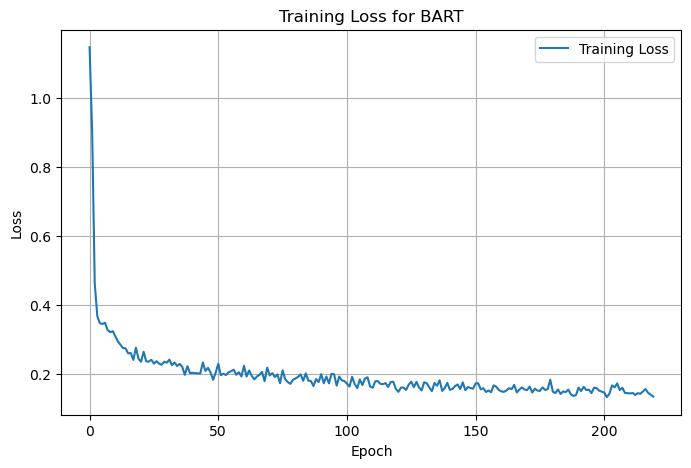

Result BART - Domain R2: 0.9874, FWHM R2: 0.8010
Model checkpoint saved to checkpoints/BART_model.pth

Benchmarking: BERT (bert-base-uncased)


Training BERT: 100%|██████████| 220/220 [08:00<00:00,  2.19s/it, loss=0.1403, lr=5.00e-06]


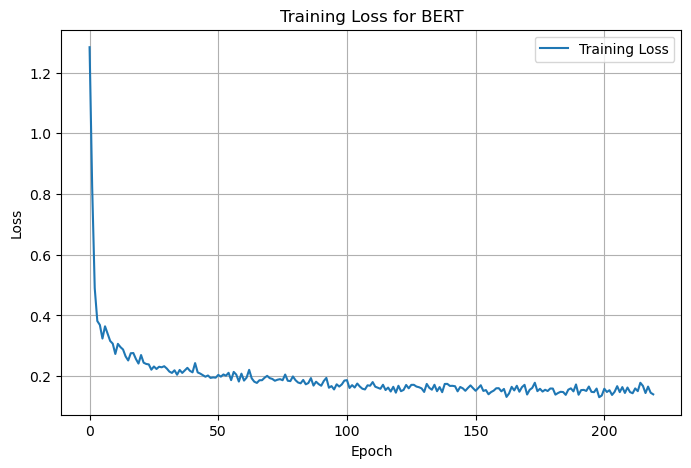

Result BERT - Domain R2: 0.9864, FWHM R2: 0.8134
Model checkpoint saved to checkpoints/BERT_model.pth

Benchmarking: ChemBERTa (seyonec/ChemBERTa-zinc-base-v1)


Training ChemBERTa: 100%|██████████| 220/220 [04:02<00:00,  1.10s/it, loss=0.1613, lr=5.00e-06]


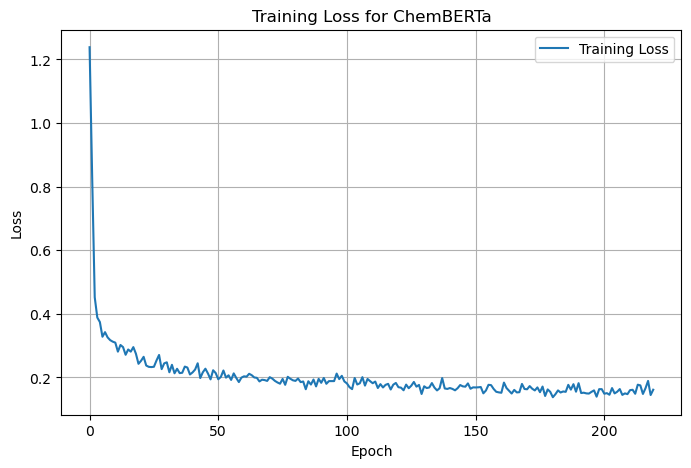

Result ChemBERTa - Domain R2: 0.9862, FWHM R2: 0.8024
Model checkpoint saved to checkpoints/ChemBERTa_model.pth

Benchmarking: PolyBERT (kuelumbus/polybert)


Training PolyBERT:   0%|          | 0/220 [00:00<?, ?it/s]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/huggingface_hub/utils/_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/models/kuelumbus/polybert'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-pa

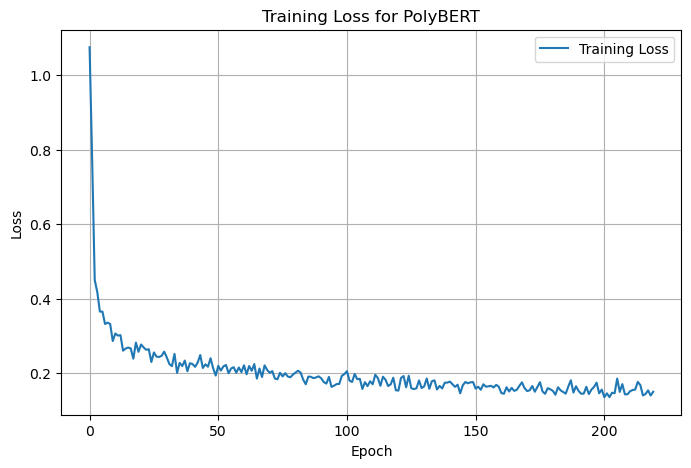

Result PolyBERT - Domain R2: 0.9845, FWHM R2: 0.8002
Model checkpoint saved to checkpoints/PolyBERT_model.pth


In [34]:

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, min_lr_ratio=0.05):
    """Create a schedule with linear warmup and cosine decay."""
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(min_lr_ratio, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

results = {}

for name, model_path in MODELS_TO_TEST.items():
    print(f"\n{'='*40}")
    print(f"Benchmarking: {name} ({model_path})")
    print(f"{'='*40}")
    
    try:
        tokenizer = load_tokenizer_cached(model_path)
    except Exception as e:
        print(f"Skipping {name}: {e}")
        continue
        
    # 2. Dataset & Loaders
    batch_size = BATCH_SIZE
    train_ds = PolymerDataset(X_text_train, X_num_train, y_train, tokenizer)
    test_ds = PolymerDataset(X_text_test, X_num_test, y_test, tokenizer)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)
    
    # 3. Model 
    model = TransformerRegressor(
        model_path, 
        num_numerical_features=X_num_train.shape[1], 
        dropout_rate=DROPOUT_RATE
    )
    model.to(device)
    
    # 4. Train - SINGLE LR for all params (found to work best)
    criterion = nn.MSELoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # Cosine LR scheduler with warmup
    num_training_steps = EPOCHS
    num_warmup_steps = int(num_training_steps * WARMUP_RATIO)
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)
    
    train_losses = []
    pbar = tqdm(range(EPOCHS), desc=f"Training {name}")
    for epoch in pbar:
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            numerical_features = batch['numerical_features'].to(device)
            targets = batch['targets'].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, numerical_features)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            
            optimizer.step()
            total_loss += loss.item()
        
        epoch_loss = total_loss / len(train_loader)
        train_losses.append(epoch_loss)
        scheduler.step()
        
        current_lr = scheduler.get_last_lr()[0]
        pbar.set_postfix({'loss': f"{epoch_loss:.4f}", 'lr': f"{current_lr:.2e}"})
        
    # Plot training loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.title(f'Training Loss for {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
        
    # 5. Evaluate
    r2_dom, r2_fwhm, preds, truths = evaluate(model, test_loader, scaler_targets)
    
    results[name] = {
        "R2_Domain": r2_dom,
        "R2_FWHM": r2_fwhm,
        "MSE_Domain": mean_squared_error(truths[:,0], preds[:,0]),
        "MSE_FWHM": mean_squared_error(truths[:,1], preds[:,1]),
        "preds": preds,
        "truths": truths
    }
    
    print(f"Result {name} - Domain R2: {r2_dom:.4f}, FWHM R2: {r2_fwhm:.4f}")
    
    # Save model checkpoint
    checkpoint_path = f"checkpoints/{name}_model.pth"
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Model checkpoint saved to {checkpoint_path}")
    
    # Clean up to save memory
    del model
    del optimizer
    del scheduler
    import gc
    gc.collect()
    torch.cuda.empty_cache()

In [ ]:
res_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

# Add Random Forest and GPR results
baseline_results = pd.DataFrame([
        {"Model": "GNNTransformer", "R2_Domain": 0.9781, "R2_FWHM": 0.8452},
    {"Model": "Random Forest", "R2_Domain": 0.991812, "R2_FWHM": 0.832733},
    {"Model": "GPR", "R2_Domain": 0.988963, "R2_FWHM": 0.823}
])
res_df = pd.concat([res_df, baseline_results], ignore_index=True)

res_df[['Model', 'R2_Domain', 'R2_FWHM']].to_csv('model_results.csv', index=False)
print("Saved to model_results.csv")

Saved to model_results.csv



[BART] Loading model from checkpoint and generating parity plots...


Loading weights: 100%|██████████| 259/259 [00:00<00:00, 2178.20it/s, Materializing param=shared.weight]                                  


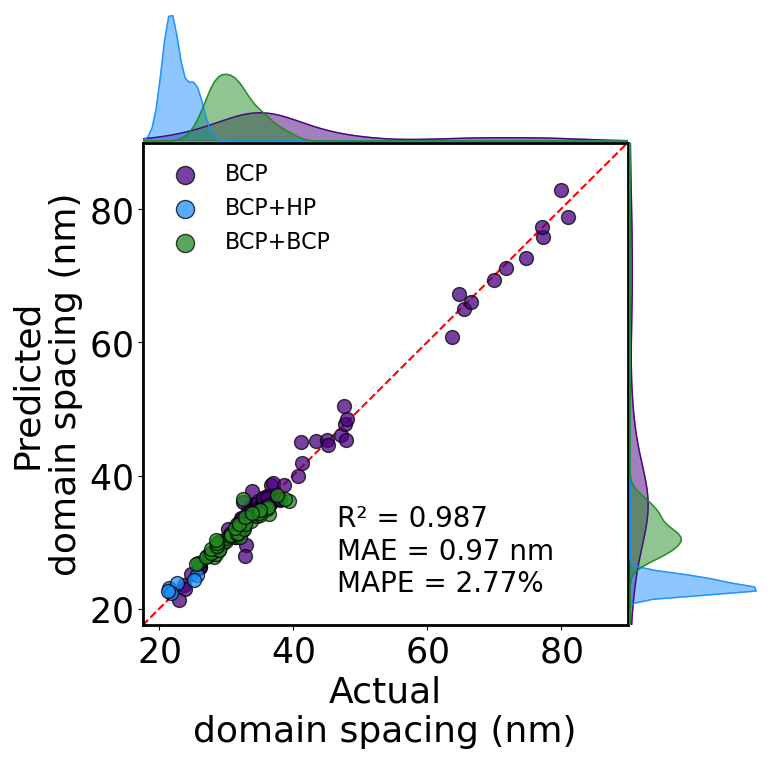

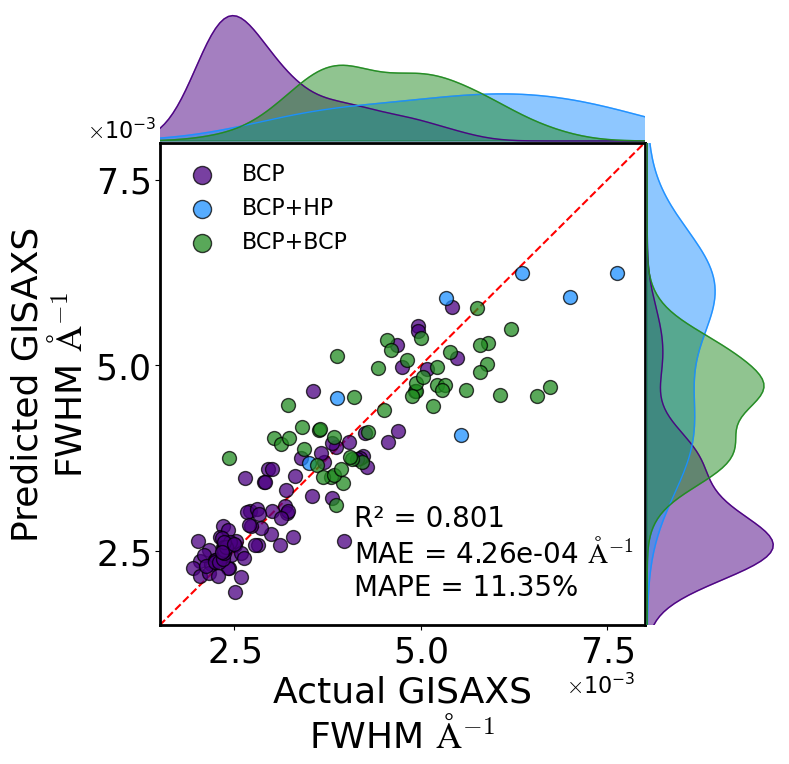


[BERT] Loading model from checkpoint and generating parity plots...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2117.66it/s, Materializing param=pooler.dense.weight]                               


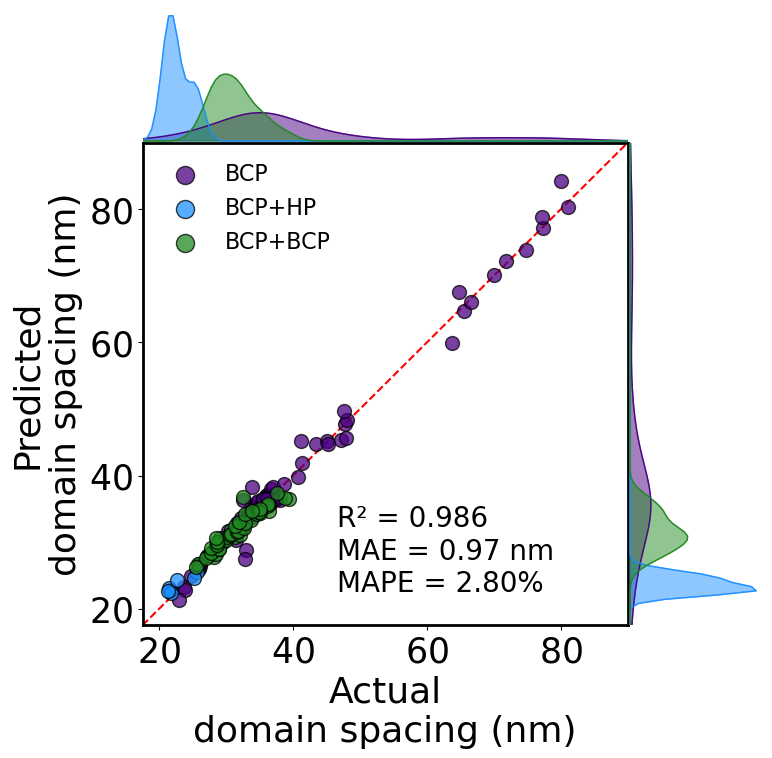

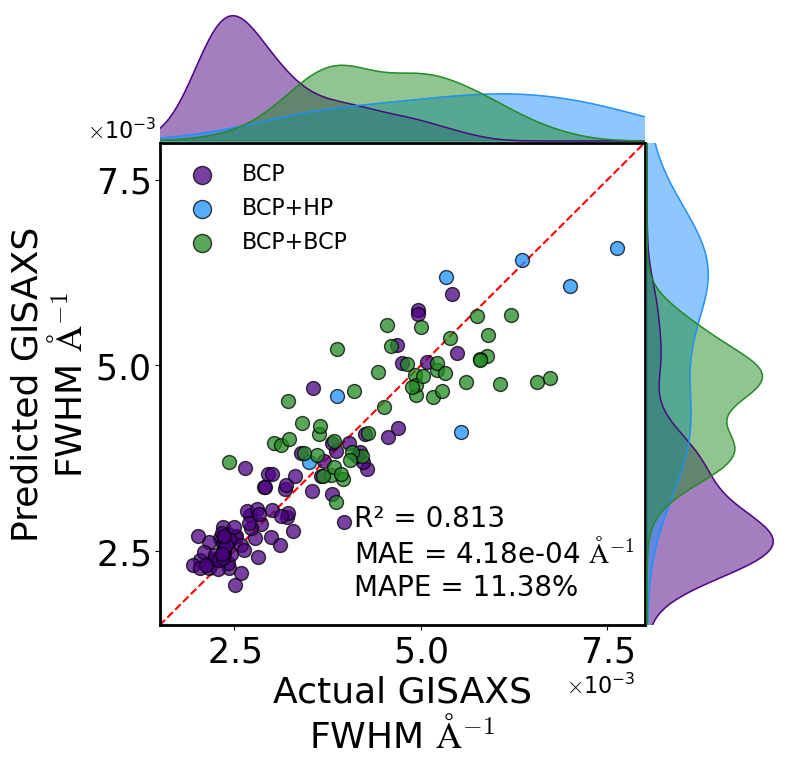


[ChemBERTa] Loading model from checkpoint and generating parity plots...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2760.61it/s, Materializing param=pooler.dense.weight]                             


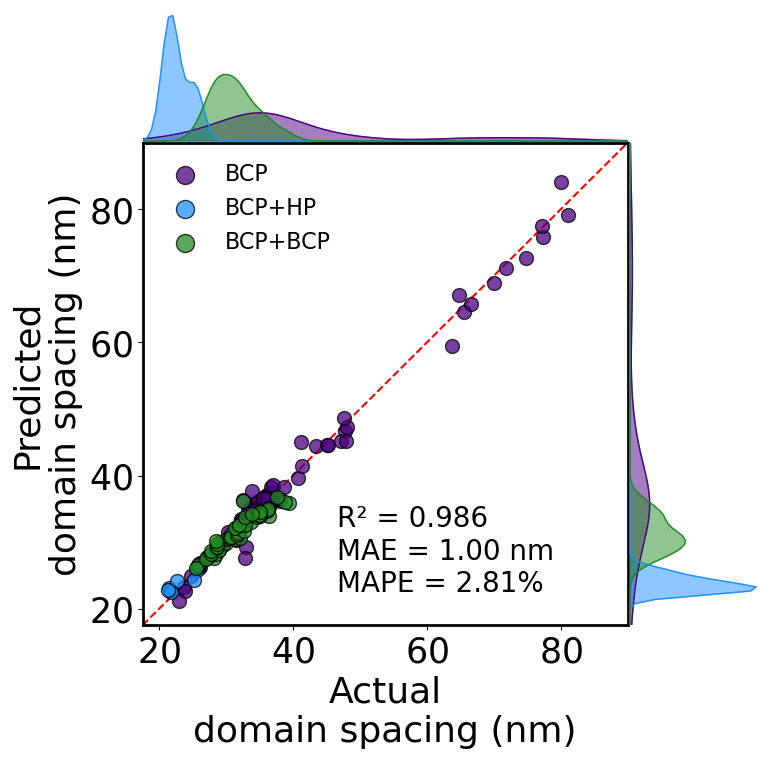

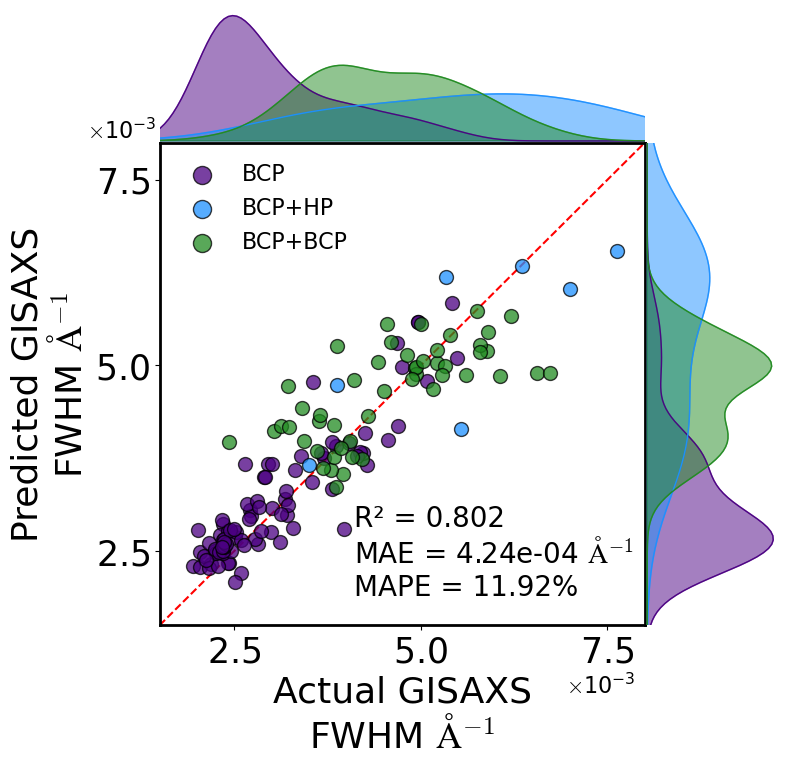


[PolyBERT] Loading model from checkpoint and generating parity plots...


Loading weights:  17%|█▋        | 33/196 [00:00<00:00, 3655.50it/s, Materializing param=encoder.layer.1.output.LayerNorm.bias]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/huggingface_hub/utils/_http.py", line 657, in hf_raise_for_status
Loading weights:  18%|█▊        | 36/196 [00:00<00:00, 3345.41it/s, Materializing param=encoder.layer.1.output.dense.weight]    response.raise_for_status()
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/httpx/_models.py", line 829, in raise_for_status
Loading weights:  19%|█▉        | 38/196 [00:00<00:00, 3311.45it/s, Materializing param=encoder.layer.2.attention.output.LayerNorm.weight]    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/models/kuelumbus/polybert'
For more information check: https://developer.mozilla

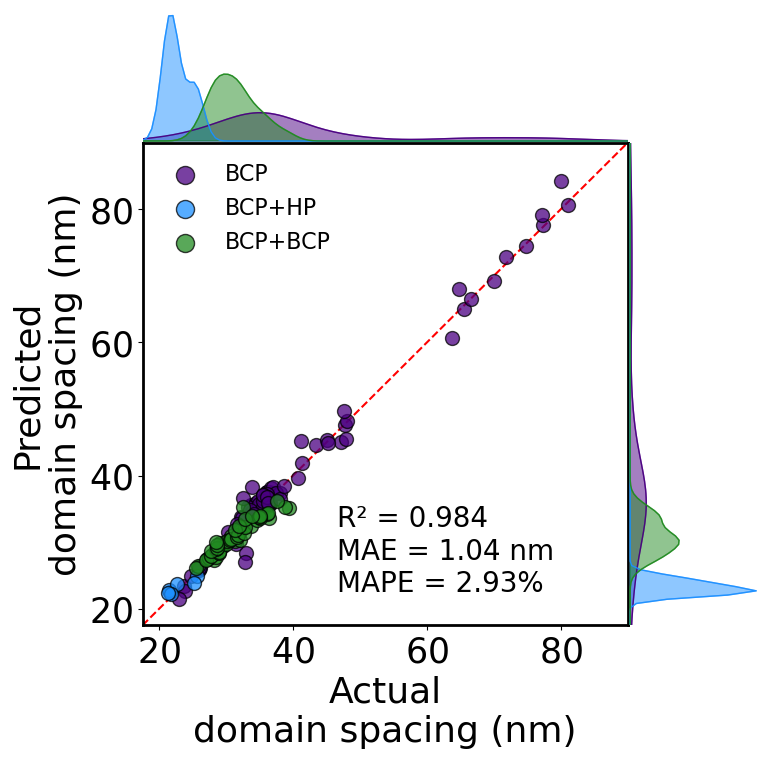

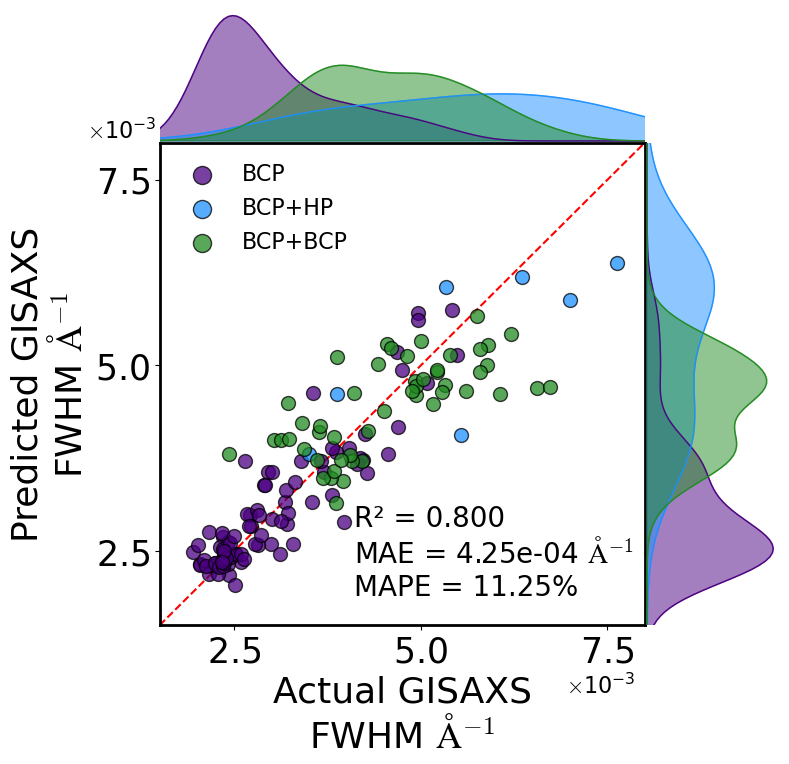

In [7]:
def classify(df):
    types = np.full(len(df), '', dtype=object)
    types[df['comp2_blockA_type'].isna() | (df['comp2_blockA_type'] == '')] = 'BCP'
    types[(~df['comp2_blockA_type'].isna() & (df['comp2_blockA_type'] != '')) & (df['comp2_blockB_type'].isna() | (df['comp2_blockB_type'] == ''))] = 'BCP+HP'
    types[(~df['comp2_blockA_type'].isna() & (df['comp2_blockA_type'] != '')) & (~df['comp2_blockB_type'].isna() & (df['comp2_blockB_type'] != ''))] = 'BCP+BCP'
    return types

def _plot_density_safe(ax, vals, lims, color, orient='x'):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 3:
        return
    if np.unique(vals).size < 2 or np.std(vals) < 1e-12:
        return
    try:
        kde = gaussian_kde(vals)
        grid = np.linspace(lims[0], lims[1], 200)
        density = kde(grid)
        if orient == 'x':
            ax.plot(grid, density, color=color, alpha=0.95, lw=1)
            ax.fill_between(grid, 0, density, color=color, alpha=0.5)
        else:
            ax.plot(density, grid, color=color, alpha=0.95, lw=1)
            ax.fill_betweenx(grid, 0, density, color=color, alpha=0.5)
    except Exception:
        pass

def plot_parity(X_test_df, y_actual, y_pred, target_name, r2_val, output_path=None, model_tag="BART", density=True):
    """Single-target parity plot with optional marginal densities."""
    y_actual = np.asarray(y_actual, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    errors = y_pred - y_actual
    mae = np.mean(np.abs(errors))
    eps = 1e-12
    mape = np.mean(np.abs(errors) / np.clip(np.abs(y_actual), eps, None)) * 100

    rc('text', usetex=False)
    rc('mathtext', fontset='cm')
    rc('xtick', labelsize=25)
    rc('ytick', labelsize=25)
    rc('axes', labelsize=25, linewidth=2, labelweight='500')
    rc('font', family='sans-serif', size=15, weight='500', style='normal')
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True

    fig = plt.figure(figsize=(8, 8))
    gs = fig.add_gridspec(2, 2, width_ratios=[7, 2], height_ratios=[2, 7], hspace=-0.015, wspace=-0.0125)
    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

    # Determine plotting limits robustly.
    lim_min = max(min(y_actual.min(), y_pred.min()), 1e-12)
    lim_max = max(y_actual.max(), y_pred.max())
    buffer = 0.5 * (lim_max - lim_min) if lim_max > lim_min else 0.5
    lims = [lim_min - buffer, lim_max + buffer]

    # Color by composition type
    types = classify(X_test_df)
    colors = {'BCP': 'indigo', 'BCP+HP': 'dodgerblue', 'BCP+BCP': 'forestgreen'}
    for label, color in colors.items():
        m = types == label
        if m.sum() == 0:
            continue
        ax_main.scatter(y_actual[m], y_pred[m], color=color, edgecolors='black', alpha=0.75, s=100, label=label, zorder=2)
        if density:
            _plot_density_safe(ax_top, y_actual[m], lims, color, orient='x')
            _plot_density_safe(ax_right, y_pred[m], lims, color, orient='y')

    # Apply target-specific limits and tick density.
    if target_name == 'domain':
        ax_main.set_xlim(17.5, 90)
        ax_main.set_ylim(17.5, 90)
        ax_top.set_xlim(17.5, 90)
        ax_right.set_ylim(17.5, 90)
        locator = MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    else:
        ax_main.set_xlim(0.0015, 0.008)
        ax_main.set_ylim(0.0015, 0.008)
        ax_top.set_xlim(0.0015, 0.008)
        ax_right.set_ylim(0.0015, 0.008)
        locator = MaxNLocator(nbins=3)

    ax_main.xaxis.set_major_locator(locator)
    ax_main.yaxis.set_major_locator(locator)

    # Perfect prediction line after axis limits are finalized.
    xlim = ax_main.get_xlim()
    ylim = ax_main.get_ylim()
    line_min = min(xlim[0], ylim[0])
    line_max = max(xlim[1], ylim[1])
    ax_main.plot([line_min, line_max], [line_min, line_max], '--', color='red', zorder=0)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, 3))
    ax_main.xaxis.set_major_formatter(formatter)
    ax_main.yaxis.set_major_formatter(formatter)
    ax_main.xaxis.offsetText.set_fontsize(16)
    ax_main.yaxis.offsetText.set_fontsize(16)
    ax_main.xaxis.get_offset_text().set_position((0.98, -0.12))
    ax_main.yaxis.get_offset_text().set_position((-0.15, 0.98))

    if target_name == 'fwhm':
        xlabel = 'Actual GISAXS\nFWHM $\\mathrm{\\AA}^{-1}$'
        ylabel = 'Predicted GISAXS\nFWHM $\\mathrm{\\AA}^{-1}$'
        unit = ' $\\mathrm{\\AA}^{-1}$'
    else:
        xlabel = 'Actual\ndomain spacing (nm)'
        ylabel = 'Predicted\ndomain spacing (nm)'
        unit = ' nm'

    ax_main.set_xlabel(xlabel, fontsize=26)
    ax_main.set_ylabel(ylabel, fontsize=26)
    ax_main.tick_params(axis='both', which='both', reset=True, top=False, right=False)
    ax_main.grid(False)
    ax_top.axis('off')
    ax_right.axis('off')

    ax_main.legend(fontsize=16, markerscale=1.3, frameon=False, loc='upper left')
    mae_s = f"{mae:.2e}" if mae < 0.01 else f"{mae:.2f}"
    mape_s = f"{mape:.2f}"
    ax_main.text(0.40, 0.25, f'R² = {r2_val:.3f}\nMAE = {mae_s}{unit}\nMAPE = {mape_s}%',
                 transform=ax_main.transAxes, fontsize=20, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0))

    if output_path:
        os.makedirs(output_path, exist_ok=True)
        plt.savefig(f"{output_path}/{model_tag}_{target_name}_parity.pdf",
                    format='pdf', bbox_inches='tight', transparent=True)

# Get the test split dataframe to match the test set based on df_split mapping
df_test_split = df[df['Sample'].map(df_split.set_index('Sample')['train/test'].to_dict()) == 'test'].copy()

# Plot for all 4 models
models_to_plot = ['BART', 'BERT', 'ChemBERTa', 'PolyBERT']

for model_name in models_to_plot:
    checkpoint_path = f"checkpoints/{model_name}_model.pth"
    
    if os.path.exists(checkpoint_path):
        print(f"\n[{model_name}] Loading model from checkpoint and generating parity plots...")
        
        try:
            model_path = MODELS_TO_TEST[model_name]
            tokenizer = load_tokenizer_cached(model_path)
            
            # Create test dataset and loader
            test_ds = PolymerDataset(X_text_test, X_num_test, y_test, tokenizer)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
            
            # Load model architecture and weights
            model = TransformerRegressor(
                model_path, 
                num_numerical_features=X_num_train.shape[1], 
                dropout_rate=DROPOUT_RATE
            )
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
            model.to(device)
            
            # Evaluate to get predictions
            r2_dom, r2_fwhm, preds_orig, truths_orig = evaluate(model, test_loader, scaler_targets)
            
            # Generate parity plots
            plot_parity(df_test_split, truths_orig[:, 0], preds_orig[:, 0], 'domain', r2_dom, 
                       output_path="results/", model_tag=model_name)
            plot_parity(df_test_split, truths_orig[:, 1], preds_orig[:, 1], 'fwhm', r2_fwhm, 
                       output_path="results/", model_tag=model_name)
            plt.show()
            
            # Clean up
            del model
            del tokenizer
            torch.cuda.empty_cache()
            
        except Exception as e:
            print(f"✗ Error loading {model_name}: {str(e)}")
    else:
        print(f"Checkpoint for {model_name} not found in checkpoints/. Please check the path or run training.")

(10, 18)
Loaded V2 dataset with 10 samples
V2 data processed: 10 samples

Evaluating PolyBERT on V2 data...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2878.41it/s, Materializing param=encoder.layer.11.output.dense.weight]              
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/huggingface_hub/utils/_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/models/kuelumbus/polybert'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/threading.py", line 1045, in _bootstrap_inner

V2 Results PolyBERT - Domain R2: -0.1827, FWHM R2: -5.1746
V2 predictions before plotting:
 sample_idx  domain_actual  domain_pred  fwhm_actual  fwhm_pred
          0      26.271004     0.798879     0.008350   0.026141
          1      31.645702     0.831779     0.012947   0.024565
          2      55.236408    28.362141     0.004833   0.010217
          3      85.464828    60.607540     0.004123   0.004494
          4      82.048637    65.454590     0.003586   0.004312
          5      57.523087    28.686255     0.005813   0.010489
          6      75.648468    60.436131     0.004038   0.004480
          7      81.898849    65.486130     0.003806   0.004364
          8      73.399460    42.922588     0.002947   0.003257
          9      34.597286    29.287645     0.004771   0.003784
NaN counts: {'sample_idx': 0, 'domain_actual': 0, 'domain_pred': 0, 'fwhm_actual': 0, 'fwhm_pred': 0}
Points outside domain plotting range (0.01, 90): 0
Points outside fwhm plotting range (0.0, 0.03): 0
Ge

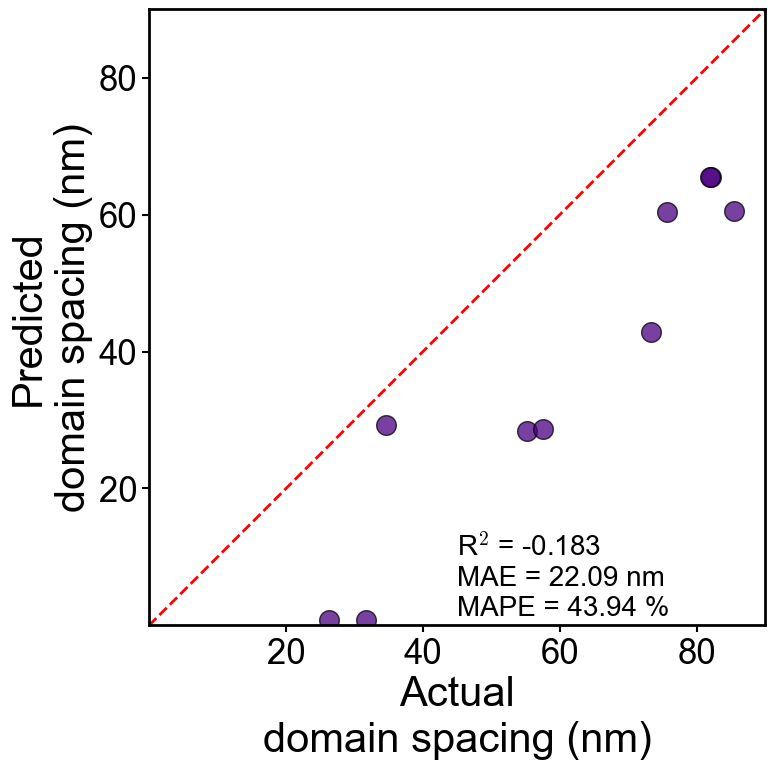

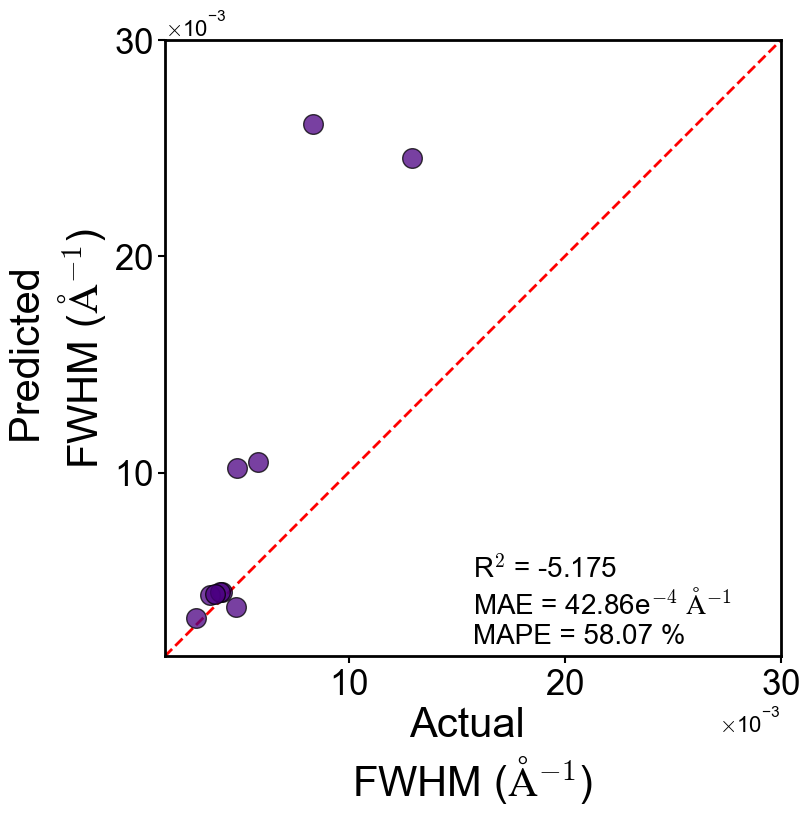

V2 results saved to model_results_v2.csv


In [8]:
# --- V2 Data Evaluation using V1 Scalers ---

def construct_text_input(row):
    parts = []
    # Comp 1
    parts.append(row['comp1_blockA_type'])
    parts.append(row['comp1_blockB_type'])
    
    # Comp 2
    if row['comp2_blockA_type']:
        parts.append(row['comp2_blockA_type'])
    if row['comp2_blockB_type']:
        parts.append(row['comp2_blockB_type'])
        
    # Additive
    if row['add_type']:
        parts.append(row['add_type'])

    # Solvents
    if row['solv_1']:
        parts.append(row['solv_1'])
    if row['solv_2']:
        parts.append(row['solv_2'])
        
    return " [SEP] ".join(parts)

def plot_pred_vs_actual_v2(y_test, y_test_pred, test_r2, model_output, output_path=None, target_name='domain'):
    y_test = np.asarray(y_test, dtype=float)
    y_test_pred = np.asarray(y_test_pred, dtype=float)
    errors = y_test_pred - y_test

    # Metrics
    mae = np.mean(np.abs(errors))
    eps = 1e-12
    mape = np.mean(np.abs(errors) / np.clip(np.abs(y_test), eps, None)) * 100
    r2 = test_r2

    # Configure figure aesthetics
    rc('text', usetex=False)
    rc('mathtext', fontset='cm')
    rc('xtick', labelsize=25)
    rc('xtick.major', size=5)
    rc('xtick.minor', size=4)
    rc('xtick.major', width=1.5)
    rc('xtick.minor', width=2)
    rc('ytick.major', width=1.5)
    rc('ytick.minor', width=2)
    rc('ytick', labelsize=25)
    rc('ytick.major', size=5)
    rc('ytick.minor', size=4)
    rc('axes', labelsize=25)
    rc('axes', linewidth=2)
    rc('font',family='sans serif')
    rc('font', style='normal')
    rc('font', weight='500')
    rc('font', size='15')
    rc('axes', labelweight='500')
    rc('axes.spines', **{'right':True, 'top':True})
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True

    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot all V2 points without category filtering.
    if target_name == 'domain':
        y_true_plot = y_test
        y_pred_plot = y_test_pred
        xlabel = 'Actual\ndomain spacing (nm)'
        ylabel = 'Predicted\ndomain spacing (nm)'
        unit_text = ' nm'
        fixed_lims = [-0.01, 90]
        ticks = [20, 40, 60, 80]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
    else:
        y_true_plot = y_test
        y_pred_plot = y_test_pred
        xlabel = 'Actual \nFWHM ($\\mathrm{{\\AA}}^{{-1}}$)'
        ylabel = 'Predicted \nFWHM ($\\mathrm{{\\AA}}^{{-1}}$)'
        unit_text = ' $\\mathrm{{\\AA}}^{{-1}}$'
        fixed_lims = [0.0015, 0.03]
        ticks = [0.01, 0.02, 0.03]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)

    ax.set_xlim(fixed_lims)
    ax.set_ylim(fixed_lims)
    ax.set_aspect('equal', adjustable='box')

    # Diagonal reference aligned with fixed axis range.
    line_min, line_max = fixed_lims
    ax.plot([line_min, line_max], [line_min, line_max], '--', color='red', zorder=0, linewidth=2.0)

    ax.scatter(
        y_true_plot,
        y_pred_plot,
        color='indigo',
        edgecolors='black',
        alpha=0.75,
        s=200
    )

    if target_name == 'fwhm':
        sci_formatter = ScalarFormatter(useMathText=True)
        sci_formatter.set_scientific(True)
        sci_formatter.set_powerlimits((-3, -3))  
        ax.xaxis.set_major_formatter(sci_formatter)
        ax.yaxis.set_major_formatter(sci_formatter)
        ax.xaxis.get_offset_text().set_fontsize(16)
        ax.yaxis.get_offset_text().set_fontsize(16)

    ax.set_xlabel(xlabel, fontsize=30)
    ax.set_ylabel(ylabel, fontsize=30)
    ax.tick_params(axis='both', which='both', reset=True, top=False, right=False)
    ax.set_facecolor('white')
    ax.grid(False)

    # Metrics Text
    if target_name == 'fwhm':
        metrics_text = (
            rf'R$^2$ = {r2:.3f}' '\n'
            rf'MAE = {mae*1e4:.2f}e$^{{-4}}${unit_text}' '\n'
            rf'MAPE = {mape:.2f} %'
        )
        ax.text(0.5, 0.165, metrics_text,
        transform=ax.transAxes,
        fontsize=20, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0))
    else:
        metrics_text = (
            rf'R$^2$ = {r2:.3f}' '\n'
            rf'MAE = {mae:.2f}{unit_text}' '\n'
            rf'MAPE = {mape:.2f} %'
        )

        ax.text(0.5, 0.15, metrics_text,
            transform=ax.transAxes,
            fontsize=20, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0))

    # Axes borders
    for spine in ax.spines.values():
        spine.set_color('black')

    #plt.tight_layout()

    # Save figure
    if output_path:
        os.makedirs(output_path, exist_ok=True)
        out_file = os.path.join(output_path, f"{model_output}_parity.pdf")
        plt.savefig(out_file, format='pdf', bbox_inches='tight', transparent=True)



# Load V2 data
v2_path = 'dataset/V2.xlsx'
if os.path.exists(v2_path):
    df2 = pd.read_excel(v2_path)
    print(df2.shape)
    print(f"Loaded V2 dataset with {len(df2)} samples")
    
    # Apply same preprocessing as V1
    string_cols = ['comp1_blockA_type', 'comp1_blockB_type', 'comp2_blockA_type', 'comp2_blockB_type', 'add_type', 'solv_1', 'solv_2']
    df2[string_cols] = df2[string_cols].fillna('')
    
    # Apply log1p to MW columns
    for col in mw_cols:
        df2[col] = np.log1p(df2[col])
    
    # Fill NaN in num_cols with 0
    df2[num_cols] = df2[num_cols].fillna(0)
    
    # Construct text_input if not present
    if 'text_input' not in df2.columns:
        df2['text_input'] = df2.apply(construct_text_input, axis=1)
    
    # Extract features
    v2_numerical_features_raw = df2[num_cols].values
    v2_text_inputs = df2['text_input'].tolist()
    
    # Get targets and apply log1p transformation
    v2_targets_original = df2[['gisaxs_domain', 'gisaxs_fwhm']].astype(float).values
    v2_targets_log1p = np.log1p(v2_targets_original)
    
    # Scale using V1 scalers
    v2_numerical_features_scaled = scaler_features.transform(v2_numerical_features_raw)
    v2_targets_scaled = scaler_targets.transform(v2_targets_log1p)
    
    print(f"V2 data processed: {len(v2_text_inputs)} samples")
    
    # Evaluate each model on V2 data
    v2_results = {}
    
    for name, model_path in MODELS_TO_TEST.items():
        if name!="PolyBERT":
            continue
        print(f"\nEvaluating {name} on V2 data...")
        
        # Load tokenizer from cache only
        tokenizer = load_tokenizer_cached(model_path)
        
        # Create V2 dataset
        v2_ds = PolymerDataset(v2_text_inputs, v2_numerical_features_scaled, v2_targets_scaled, tokenizer)
        v2_loader = DataLoader(v2_ds, batch_size=BATCH_SIZE)
        
        # Load trained model
        checkpoint_path = f"checkpoints/{name}_model.pth"
        if os.path.exists(checkpoint_path):
            model = TransformerRegressor(model_path, num_numerical_features=N_NUM_FEATS, dropout_rate=DROPOUT_RATE)
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
            model.to(device)
            
            # Evaluate
            r2_dom_v2, r2_fwhm_v2, preds_v2, truths_v2 = evaluate(model, v2_loader, scaler_targets)
            
            v2_results[name] = {
                "R2_Domain_V2": r2_dom_v2,
                "R2_FWHM_V2": r2_fwhm_v2,
                "MSE_Domain_V2": mean_squared_error(truths_v2[:,0], preds_v2[:,0]),
                "MSE_FWHM_V2": mean_squared_error(truths_v2[:,1], preds_v2[:,1])
            }
            
            print(f"V2 Results {name} - Domain R2: {r2_dom_v2:.4f}, FWHM R2: {r2_fwhm_v2:.4f}")
            
            # Print per-sample predictions before plotting to debug missing points.
            v2_pred_table = pd.DataFrame({
                'sample_idx': np.arange(len(truths_v2)),
                'domain_actual': truths_v2[:, 0],
                'domain_pred': preds_v2[:, 0],
                'fwhm_actual': truths_v2[:, 1],
                'fwhm_pred': preds_v2[:, 1],
            })
            print("V2 predictions before plotting:")
            print(v2_pred_table.to_string(index=False))
            print("NaN counts:", v2_pred_table.isna().sum().to_dict())
            
            domain_lims = (0.01, 90)
            fwhm_lims = (0.0, 0.03)
            domain_outside = ((v2_pred_table['domain_actual'] < domain_lims[0]) | (v2_pred_table['domain_actual'] > domain_lims[1]) |
                              (v2_pred_table['domain_pred'] < domain_lims[0]) | (v2_pred_table['domain_pred'] > domain_lims[1]))
            fwhm_outside = ((v2_pred_table['fwhm_actual'] < fwhm_lims[0]) | (v2_pred_table['fwhm_actual'] > fwhm_lims[1]) |
                            (v2_pred_table['fwhm_pred'] < fwhm_lims[0]) | (v2_pred_table['fwhm_pred'] > fwhm_lims[1]))
            print(f"Points outside domain plotting range {domain_lims}: {int(domain_outside.sum())}")
            print(f"Points outside fwhm plotting range {fwhm_lims}: {int(fwhm_outside.sum())}")
            
            # Generate parity plots for V2 without category filtering.
            print(f"Generating V2 parity plots for {name}...")
            plot_pred_vs_actual_v2(
                y_test=truths_v2[:, 0],
                y_test_pred=preds_v2[:, 0],
                test_r2=r2_dom_v2,
                model_output=f"{name}_V2_domain",
                output_path="results/v2/",
                target_name='domain'
            )
            plt.show()

            plot_pred_vs_actual_v2(
                y_test=truths_v2[:, 1],
                y_test_pred=preds_v2[:, 1],
                test_r2=r2_fwhm_v2,
                model_output=f"{name}_V2_fwhm",
                output_path="results/v2/",
                target_name='fwhm'
            )
            plt.show()

            # Clean up
            del model
            torch.cuda.empty_cache()
        else:
            print(f"Checkpoint not found for {name}")
    
    # Save V2 results
    v2_res_df = pd.DataFrame(v2_results).T.reset_index().rename(columns={"index": "Model"})
    v2_res_df.to_csv('model_results_v2.csv', index=False)
    print("V2 results saved to model_results_v2.csv")
    
else:
    print(f"V2 data not found at {v2_path}")

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2852.79it/s, Materializing param=encoder.layer.11.output.dense.weight]              
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/huggingface_hub/utils/_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/models/kuelumbus/polybert'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/monster/anaconda3/envs/llm_env/lib/python3.11/threading.py", line 1045, in _bootstrap_inner

Generating embeddings for 143 background and 143 explanation samples...

--- Explaining Domain Spacing ---
Computing SHAP values for 143 samples...


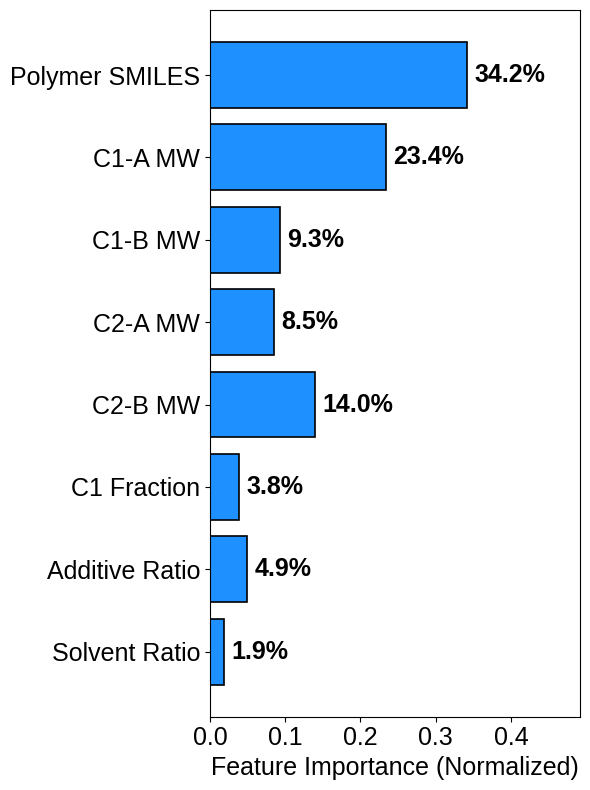

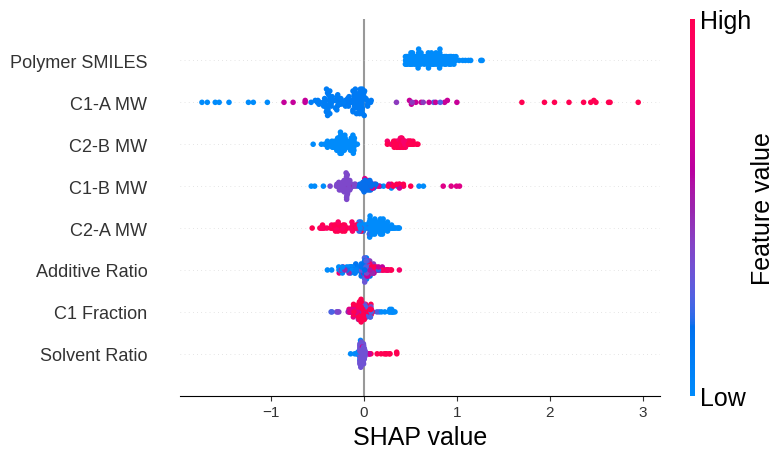


--- Explaining FWHM ---
Computing SHAP values for 143 samples...


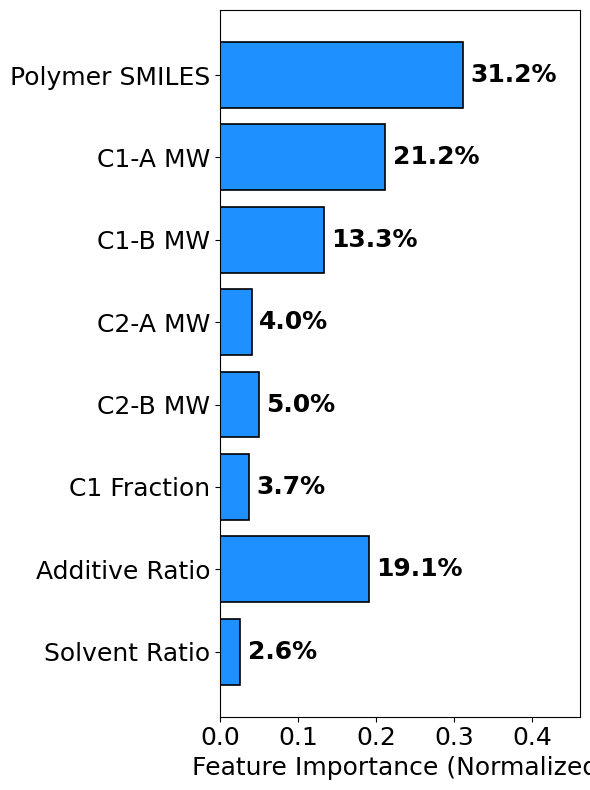

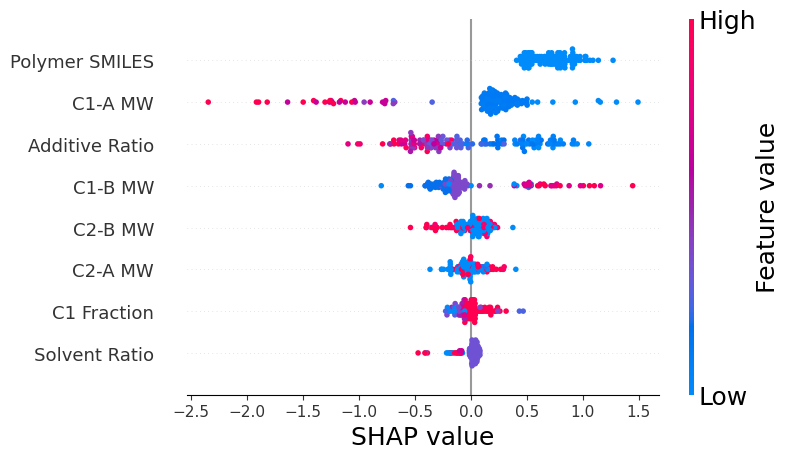

In [ ]:
import shap
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_NAME = "PolyBERT"
model_path = MODELS_TO_TEST[MODEL_NAME]
checkpoint_path = f"checkpoints/{MODEL_NAME}_model.pth"

tokenizer = load_tokenizer_cached(model_path)
model = TransformerRegressor(model_path, num_numerical_features=X_num_train.shape[1], dropout_rate=DROPOUT_RATE)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
# 2. Define Feature Names and Renaming List
raw_feature_names = ["Text Input", "MW1_A", "MW1_B", "MW2_A", "MW2_B", "Frac1", "AddRatio", "SolvRatio"]
# Renaming for better visualization
feature_names_display = [
    "Polymer SMILES", 
    "C1-A MW", 
    "C1-B MW", 
    "C2-A MW", 
    "C2-B MW", 
    "C1 Fraction", 
    "Additive Ratio", 
    "Solvent Ratio"
]

class ModelWrapper(nn.Module):
    """Wrapper to handle multi-input model for SHAP using embeddings"""
    def __init__(self, model, target_idx=0):
        super().__init__()
        self.model = model
        self.target_idx = target_idx
    
    def forward(self, text_emb, num_feats):
        """
        text_emb: (batch, hidden_size) - already embedded text
        num_feats: (batch, num_features) - numerical features
        Returns: (batch, 1) - target prediction
        """
        # Project numerical features
        num_emb = self.model.num_projection(num_feats)
        
        # Fusion
        fused = torch.cat((text_emb, num_emb), dim=1)
        
        # Return specific target
        if self.target_idx == 0:
            output = self.model.domain_trunk(fused)
        else:
            output = self.model.fwhm_trunk(fused)
        
        return output

n_total_test = len(X_text_test)
n_background = min(200, n_total_test)
n_explain = min(500, n_total_test)
seq_len = 128

print(f"Generating embeddings for {n_background} background and {n_explain} explanation samples...")

def get_text_embeddings(texts, model, tokenizer, device):
    """Get text embeddings from the transformer encoder"""
    inputs = tokenizer(texts, padding='max_length', truncation=True, 
                      max_length=seq_len, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.transformer(input_ids=inputs['input_ids'], 
                                   attention_mask=inputs['attention_mask'])
        last_hidden_state = outputs.last_hidden_state
        text_emb = model.attention_pool(last_hidden_state, inputs['attention_mask'])
    return text_emb

# Background and Explanation data
X_text_bg = X_text_test[:n_background]
X_num_bg = X_num_test[:n_background, :]
text_emb_bg = get_text_embeddings(X_text_bg, model, tokenizer, device)
num_bg = torch.tensor(X_num_bg, dtype=torch.float).to(device)

X_text_exp = X_text_test[:n_explain]
X_num_exp = X_num_test[:n_explain, :]
text_emb_exp = get_text_embeddings(X_text_exp, model, tokenizer, device)
num_exp = torch.tensor(X_num_exp, dtype=torch.float).to(device)

targets_to_explain = [("Domain Spacing", 0), ("FWHM", 1)]

X_combined_exp = np.column_stack([np.zeros(n_explain), X_num_exp])

for target_name, target_idx in targets_to_explain:
    print(f"\n--- Explaining {target_name} ---")
    
    # Wrap model for specific target
    wrapped_model = ModelWrapper(model, target_idx=target_idx)
    wrapped_model.eval()

    # 5. Initialize SHAP GradientExplainer
    explainer = shap.GradientExplainer(wrapped_model, [text_emb_bg, num_bg])

    # 6. Compute SHAP values
    print(f"Computing SHAP values for {n_explain} samples...")
    shap_values = explainer.shap_values([text_emb_exp, num_exp])

    # 7. Aggregate SHAP values
    text_shap_raw = shap_values[0]
    if text_shap_raw.ndim == 3:
        text_shap_raw = np.squeeze(text_shap_raw, axis=-1)
    
    text_shap_agg = np.abs(text_shap_raw).sum(axis=1)
    
    num_shap = shap_values[1]
    if num_shap.ndim == 3:
        num_shap = np.squeeze(num_shap, axis=-1)

    if text_shap_agg.ndim == 1:
        text_shap_agg = text_shap_agg.reshape(-1, 1)
        
    all_shap = np.column_stack([text_shap_agg, num_shap])

    # 8. Horizontal Bar Plot
    mean_abs_shap = np.abs(all_shap).mean(axis=0)
    normalized_importance = mean_abs_shap / (mean_abs_shap.sum() + 1e-9)

    plt.figure(figsize=(6, 8))
    plt.barh(feature_names_display, normalized_importance, color='dodgerblue', edgecolor='black', linewidth=1.2)
    max_val = normalized_importance.max()
    plt.xlim(0, max_val + 0.15)
    for i, val in enumerate(normalized_importance):
        plt.text(val + 0.01, i, f'{val*100:.1f}%', ha='left', va='center', fontsize=18, fontweight='bold')
    plt.xlabel("Feature Importance (Normalized)", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    #plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # 9. Beeswarm Plot
    plt.figure(figsize=(12, 8))
    # Using matplotlib rcParams to influence SHAP's internal plotting
    plt.rc('xtick', labelsize=18)
    plt.rc('ytick', labelsize=18)
    
    shap.summary_plot(
        all_shap, 
        features=X_combined_exp, 
        feature_names=feature_names_display, 
        plot_type="dot", 
        show=False
    )
    
    # Update axes labels and colorbar label font size
    ax = plt.gca()
    ax.set_xlabel("SHAP value", fontsize=18)
    
    # Find the colorbar and update its label and ticks
    for child in plt.gcf().get_children():
        if isinstance(child, plt.Axes) and child != ax:
            child.set_ylabel("Feature value", fontsize=18)
            child.tick_params(labelsize=18)

    plt.tight_layout()
    plt.show()
    
    # Reset rcParams to avoid affecting other plots
    plt.rcdefaults()
